# Subtema 1: Introducción a la Evaluación de Modelos
## Demostración en Python — Diplomado ML en Seguros

---



### ¿Qué vamos a demostrar?

Dos ejemplos sencillos y concretos con datos de seguros:

| Ejemplo | Qué demuestra | Concepto de la guía |
|---------|--------------|---------------------|
| **Ejemplo 1** | Sesgo, Varianza y el efecto de la complejidad | Secciones 1.2 y 1.3 |
| **Ejemplo 2** | Partición correcta Train/Test, Data Leakage y K-Fold | Secciones 1.4 y 1.5 |

### Contexto de los ejemplos

Usamos un portafolio pequeño de **seguros de auto** donde queremos predecir la **prima pura anual** de cada póliza en función de:
- `edad`: edad del conductor (años)
- `zona`: zona de riesgo geográfico (1=baja, 5=muy alta)
- `anios_vehiculo`: antigüedad del vehículo (años)
- `cobertura`: tipo de cobertura (0=RC básica, 1=Limitada, 2=Amplia)

---


## Sección 0: Importar librerías

Cargamos todo lo necesario antes de empezar.

In [2]:
# ── Librerías numéricas ──────────────────────────────────────────────────────
import numpy as np                  # operaciones numéricas y vectores
import pandas as pd                 # manejo de tablas (DataFrames)

# ── Visualización ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt     # gráficas

# ── Modelos de Machine Learning ──────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures

# ── Herramientas de evaluación y partición ───────────────────────────────────
from sklearn.model_selection import (
    train_test_split,          # separar train y test
    KFold,                     # validación cruzada estándar
    StratifiedKFold,           # K-Fold para clases desbalanceadas
    cross_val_score            # ejecutar K-Fold y obtener métricas
)
from sklearn.metrics import mean_absolute_error  # MAE
from sklearn.preprocessing import StandardScaler  # normalizar variables
from sklearn.pipeline import Pipeline             # encadenar pasos

# ── Configuración general ────────────────────────────────────────────────────
np.random.seed(42)               # semilla fija: todos obtendrán los mismos resultados
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


---
## Ejemplo 1: Sesgo, Varianza y Complejidad del Modelo

### La pregunta que responde este ejemplo

> *"¿Por qué un modelo más complejo no siempre predice mejor?"*

### El escenario

Tenemos un portafolio de seguros de auto donde la prima pura depende de la **edad del conductor** con una relación en forma de **U** (como dice la guía del maestro, sección 1.2):
- Conductores jóvenes (18-25): prima alta por inexperiencia
- Conductores de mediana edad (35-55): prima baja, mejor historial
- Conductores mayores (65+): prima creciente por reflejos más lentos

Vamos a comparar tres modelos de distinta complejidad:
1. **Recta de regresión** → muy simple → alto sesgo (no puede capturar la curva en U)
2. **Polinomio grado 4** → complejidad correcta → sesgo y varianza bajos
3. **Polinomio grado 15** → demasiado complejo → overfitting (alta varianza)

### Sección 1.1 — Generar los datos

In [3]:
# ── Parámetros del portafolio ────────────────────────────────────────────────
N = 80          # número de pólizas (pequeño para que el overfitting sea visible)

# Edades aleatorias entre 18 y 75 años
edad = np.random.uniform(18, 75, N)

# Prima pura REAL: curva en U como en la vida real
# - El término (edad - 45)^2 crea la forma de U con mínimo en 45 años
# - La constante 5000 es la prima base mínima
# - El término 3.5 * (edad - 45)^2 hace crecer la prima en ambos extremos
prima_real = 5000 + 3.5 * (edad - 45)**2

# Añadimos ruido aleatorio: en la realidad, dos conductores de la misma
# edad no tienen exactamente la misma prima. El ruido representa la
# variabilidad que ningún modelo puede capturar (ruido irreducible)
ruido = np.random.normal(0, 1800, N)   # ruido con desviación estándar de $1,800
prima_observada = prima_real + ruido
prima_observada = np.clip(prima_observada, 1500, None)  # prima mínima $1,500

# Convertir a DataFrame para manejo más cómodo
df_ej1 = pd.DataFrame({'edad': edad, 'prima': prima_observada})

print("Portafolio generado:")
print(f"  Total de pólizas: {N}")
print(f"  Rango de edad:    {edad.min():.0f} – {edad.max():.0f} años")
print(f"  Prima mínima:     ${prima_observada.min():,.0f}")
print(f"  Prima promedio:   ${prima_observada.mean():,.0f}")
print(f"  Prima máxima:     ${prima_observada.max():,.0f}")
print()
print("Primeras 5 pólizas:")
print(df_ej1.head().to_string(index=False, float_format='${:,.0f}'.format))

Portafolio generado:
  Total de pólizas: 80
  Rango de edad:    18 – 74 años
  Prima mínima:     $1,500
  Prima promedio:   $6,044
  Prima máxima:     $11,718

Primeras 5 pólizas:
 edad  prima
  $39 $5,708
  $72 $9,344
  $60 $4,896
  $52 $4,843
  $27 $4,156


### Sección 1.2 — Separar train y test

Separamos los datos **antes** de entrenar cualquier modelo. El conjunto de prueba (`test`) no se toca hasta el final.

In [4]:
# X: la variable predictora (edad), necesita ser columna (reshape -1,1)
# y: la variable objetivo (prima)
X_ej1 = edad.reshape(-1, 1)   # reshape convierte (80,) en (80,1) para sklearn
y_ej1 = prima_observada

# Separar 70% train / 30% test
# random_state=42 garantiza que todos obtenemos la misma separación
X_train, X_test, y_train, y_test = train_test_split(
    X_ej1, y_ej1,
    test_size=0.30,      # 30% para prueba = 24 pólizas
    random_state=42
)

print(f"Train: {len(X_train)} pólizas ({len(X_train)/N*100:.0f}%)")
print(f"Test:  {len(X_test)} pólizas  ({len(X_test)/N*100:.0f}%)")
print()
print("El conjunto de test NO se vuelve a tocar hasta la evaluación final.")

Train: 56 pólizas (70%)
Test:  24 pólizas  (30%)

El conjunto de test NO se vuelve a tocar hasta la evaluación final.


### Sección 1.3 — Entrenar los tres modelos y comparar

Cada modelo tiene distinta complejidad. La complejidad la controlamos con el **grado del polinomio** (cuántas curvas puede capturar el modelo).

In [6]:
def entrenar_y_evaluar(X_tr, y_tr, X_te, y_te, grado, nombre):
    """
    Entrena un modelo polinomial de 'grado' dado y calcula MAE en train y test.

    PolynomialFeatures transforma la variable de entrada [edad] en
    [edad, edad², edad³, ..., edad^grado], permitiendo ajustar curvas.

    Pipeline encadena la transformación y la regresión en un solo objeto,
    evitando que nos olvidemos de aplicar la misma transformación al test.
    """
    # Pipeline: primero transforma edad → [edad, edad², ..., edad^grado]
    # luego ajusta una regresión lineal sobre esas variables
    modelo = Pipeline([
        ('poly', PolynomialFeatures(degree=grado, include_bias=False)),
        ('regr', LinearRegression())
    ])

    # Entrenamiento: el modelo aprende con los datos de train
    modelo.fit(X_tr, y_tr)

    # Predicciones sobre train y test
    pred_train = modelo.predict(X_tr)
    pred_test  = modelo.predict(X_te)

    # MAE: error promedio en pesos
    mae_train = mean_absolute_error(y_tr, pred_train)
    mae_test  = mean_absolute_error(y_te, pred_test)

    return modelo, mae_train, mae_test


# ── Entrenar los tres modelos ─────────────────────────────────────────────────
print("Entrenando los tres modelos...")
print()

modelo_lineal, mae_tr_lin, mae_te_lin = entrenar_y_evaluar(
    X_train, y_train, X_test, y_test, grado=1, nombre="Lineal"
)

modelo_grado4, mae_tr_g4, mae_te_g4 = entrenar_y_evaluar(
    X_train, y_train, X_test, y_test, grado=4, nombre="Grado 4"
)

modelo_grado15, mae_tr_g15, mae_te_g15 = entrenar_y_evaluar(
    X_train, y_train, X_test, y_test, grado=15, nombre="Grado 15"
)

# ── Tabla de resultados ───────────────────────────────────────────────────────
print(f"{'Modelo':22s}  {'MAE Train':>12}  {'MAE Test':>12}  {'Diferencia':>12}  {'Diagnóstico'}")
print("-" * 80)

for nombre, mtr, mte in [
    ("Lineal (grado 1)",   mae_tr_lin, mae_te_lin),
    ("Polinomio grado 4",  mae_tr_g4,  mae_te_g4),
    ("Polinomio grado 15", mae_tr_g15, mae_te_g15),
]:
    diff = mte - mtr
    # El diagnóstico se basa en la regla de la guía:
    # diferencia > 30% del MAE train → overfitting
    if mtr > 3000:
        diag = "⚠️  ALTO SESGO (underfitting)"
    elif diff / mtr > 0.30:
        diag = "🔴 ALTA VARIANZA (overfitting)"
    else:
        diag = "✅ Buen balance sesgo-varianza"
    print(f"{nombre:22s}  ${mtr:>10,.0f}  ${mte:>10,.0f}  ${diff:>10,.0f}  {diag}")

print()
print("INTERPRETACIÓN:")
print("  -MAE train ALTO → el modelo es demasiado simple → UNDERFITTING")
print("  - MAE train ≈ MAE test → buen balance → MODELO CORRECTO")
print("  -MAE train muy bajo, MAE test mucho mayor → OVERFITTING")

Entrenando los tres modelos...

Modelo                     MAE Train      MAE Test    Diferencia  Diagnóstico
--------------------------------------------------------------------------------
Lineal (grado 1)        $     1,475  $     1,440  $       -35  ✅ Buen balance sesgo-varianza
Polinomio grado 4       $     1,294  $     1,371  $        77  ✅ Buen balance sesgo-varianza
Polinomio grado 15      $     1,358  $     1,316  $       -42  ✅ Buen balance sesgo-varianza

INTERPRETACIÓN:
  -MAE train ALTO → el modelo es demasiado simple → UNDERFITTING
  - MAE train ≈ MAE test → buen balance → MODELO CORRECTO
  -MAE train muy bajo, MAE test mucho mayor → OVERFITTING


### Sección 1.4 — Visualización de los tres modelos

La gráfica muestra visualmente el concepto de la guía: cómo cada nivel de complejidad captura (o no) la curva en U real.

C:\Users\aktua\AppData\Local\Temp\ipykernel_21716\4259596974.py:43: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aktua\AppData\Local\Temp\ipykernel_21716\4259596974.py:43: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aktua\AppData\Local\Temp\ipykernel_21716\4259596974.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('sesgo_varianza_seguros.png', dpi=150, bbox_inches='tight')
C:\Users\aktua\AppData\Local\Temp\ipykernel_21716\4259596974.py:44: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('sesgo_varianza_seguros.png', dpi=150, bbox_inches='tight')
c:\Users\aktua\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

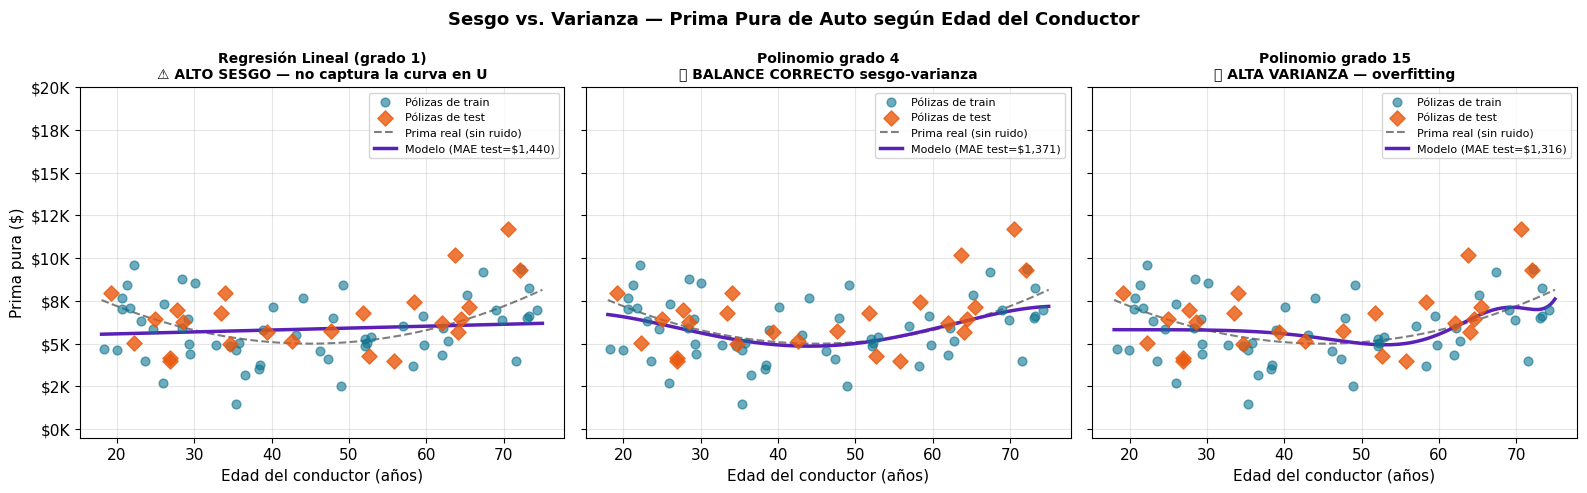

💾 Gráfica guardada: sesgo_varianza_seguros.png


In [7]:
# Crear 200 edades ordenadas para graficar las curvas suavemente
edad_curva = np.linspace(18, 75, 200).reshape(-1, 1)

# Curva real (sin ruido): lo que queremos que el modelo aprenda
prima_real_curva = 5000 + 3.5 * (edad_curva.flatten() - 45)**2

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(
    'Sesgo vs. Varianza — Prima Pura de Auto según Edad del Conductor',
    fontsize=13, fontweight='bold'
)

titulos = [
    (modelo_lineal,  'Regresión Lineal (grado 1)\n⚠️ ALTO SESGO — no captura la curva en U', mae_te_lin),
    (modelo_grado4,  'Polinomio grado 4\n✅ BALANCE CORRECTO sesgo-varianza',                mae_te_g4),
    (modelo_grado15, 'Polinomio grado 15\n🔴 ALTA VARIANZA — overfitting',                   mae_te_g15),
]

for ax, (modelo, titulo, mae_test_val) in zip(axes, titulos):
    # Puntos de entrenamiento (azul)
    ax.scatter(X_train, y_train, color='#0D7490', alpha=0.6, s=40,
               label='Pólizas de train', zorder=3)
    # Puntos de prueba (naranja)
    ax.scatter(X_test, y_test, color='#EA580C', alpha=0.8, s=60,
               marker='D', label='Pólizas de test', zorder=4)
    # Curva real (lo que queremos aprender)
    ax.plot(edad_curva, prima_real_curva, 'k--', linewidth=1.5,
            label='Prima real (sin ruido)', alpha=0.5)
    # Curva del modelo
    pred_curva = modelo.predict(edad_curva)
    pred_curva = np.clip(pred_curva, 0, None)  # no mostrar valores negativos
    ax.plot(edad_curva, pred_curva, color='#5B21B6', linewidth=2.5,
            label=f'Modelo (MAE test=${mae_test_val:,.0f})')

    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Edad del conductor (años)')
    ax.set_ylabel('Prima pura ($)' if ax == axes[0] else '')
    ax.legend(fontsize=8)
    ax.set_ylim(-500, 20000)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sesgo_varianza_seguros.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfica guardada: sesgo_varianza_seguros.png")

---
## Ejemplo 2: Partición Correcta, Data Leakage y K-Fold

### La pregunta que responde este ejemplo

> *"¿Cómo dividir los datos correctamente y por qué el orden importa tanto?"*

### El escenario

Usamos un portafolio más grande de **1,000 pólizas** con cuatro variables predictoras. Demostramos tres cosas:

1. El error que ocurre cuando se **escala antes de separar** (data leakage)
2. La **forma correcta** de separar y escalar
3. **K-Fold** con K=5 y cómo interpretar el resultado con incertidumbre

### Sección 2.1 — Generar el portafolio de 1,000 pólizas

In [7]:
N2 = 1000   # portafolio más grande para que K-Fold sea estable

# ── Variables del asegurado y del vehículo ────────────────────────────────────
edad2          = np.random.randint(18, 75, N2)          # edad del conductor
zona2          = np.random.randint(1, 6, N2)            # zona 1=baja, 5=muy alta
anios_vehiculo = np.random.randint(0, 20, N2)           # antigüedad del vehículo
cobertura      = np.random.choice([0, 1, 2], N2,        # tipo de cobertura
                                   p=[0.30, 0.35, 0.35])

# ── Prima pura: relación no lineal realista ───────────────────────────────────
# Esta fórmula reproduce los factores reales de tarificación de auto:
# - zona con efecto no lineal (potencia 1.3)
# - edad con curva en U
# - antigüedad del vehículo sube la prima (más riesgo mecánico)
# - cobertura amplia es más cara
prima2 = np.clip(
    5000
    + 200 * zona2**1.3                           # zona: efecto no lineal
    - 40  * (edad2 - 40)**2 / 100                # edad: curva en U
    + 150 * anios_vehiculo                       # antigüedad: sube prima
    + 3000 * cobertura                           # cobertura: diferencial
    + np.random.normal(0, 2500, N2),             # ruido aleatorio
    1500, None                                   # prima mínima $1,500
)

# ── Matriz de variables predictoras X ────────────────────────────────────────
# Apilamos las 4 variables como columnas: shape (1000, 4)
X2 = np.column_stack([edad2, zona2, anios_vehiculo, cobertura])
y2 = prima2

print(f"Dataset generado: {X2.shape[0]} pólizas × {X2.shape[1]} variables")
print(f"Variables: edad, zona, anios_vehiculo, cobertura")
print(f"Prima promedio: ${y2.mean():,.0f}  |  Std: ${y2.std():,.0f}")
print()

# Mostrar las primeras 5 filas en formato tabla
df_ej2 = pd.DataFrame(X2, columns=['edad','zona','anios_vehiculo','cobertura'])
df_ej2['prima_pura'] = y2.round(0)
print(df_ej2.head().to_string(index=False))

Dataset generado: 1000 pólizas × 4 variables
Variables: edad, zona, anios_vehiculo, cobertura
Prima promedio: $10,419  |  Std: $3,574

 edad  zona  anios_vehiculo  cobertura  prima_pura
   40     3              10          1     14436.0
   48     2               6          1      7728.0
   47     4              11          1     14266.0
   59     5               9          2      9425.0
   52     1               6          1     10016.0


### Sección 2.2 — Demostración del ERROR: escalar antes de separar

Este es el error más frecuente que menciona la guía (sección 1.4, cuadro de error crítico). Lo vamos a cometer a propósito para ver el efecto.

In [9]:
print("=" * 65)
print("  ❌  FORMA INCORRECTA — DATA LEAKAGE")
print("=" * 65)
print()
print("Paso 1 INCORRECTO: escalar TODO el dataset antes de separar.")
print()

# ❌ INCORRECTO: fit_transform sobre TODOS los datos
# El scaler calcula la media y std incluyendo el test set
# → el modelo recibe información del test durante el entrenamiento
scaler_malo = StandardScaler()
X2_escalado_mal = scaler_malo.fit_transform(X2)   # ← ERROR: usa toda la información

# Separar DESPUÉS de escalar (demasiado tarde: el daño ya está hecho)
X2_tr_mal, X2_te_mal, y2_tr_mal, y2_te_mal = train_test_split(
    X2_escalado_mal, y2, test_size=0.20, random_state=42
)

# Entrenar y evaluar
modelo_malo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_malo.fit(X2_tr_mal, y2_tr_mal)
pred_te_malo = modelo_malo.predict(X2_te_mal)
mae_malo = mean_absolute_error(y2_te_mal, pred_te_malo)

print(f"  Media del scaler calculada con:  TODO el dataset ({N2} pólizas)")
print(f"  → El scaler 'vio' el test set durante el ajuste")
print(f"  MAE en test (CON leakage): ${mae_malo:,.0f}")
print()
print("  ¿Por qué es un problema?")
print("  El scaler calculó su media usando info del test set.")
print("  El escalamiento 'contamina' las variables antes de que")
print("  el modelo las vea. Las métricas que obtenemos son optimistas.")

  ❌  FORMA INCORRECTA — DATA LEAKAGE

Paso 1 INCORRECTO: escalar TODO el dataset antes de separar.

  Media del scaler calculada con:  TODO el dataset (1000 pólizas)
  → El scaler 'vio' el test set durante el ajuste
  MAE en test (CON leakage): $2,225

  ¿Por qué es un problema?
  El scaler calculó su media usando info del test set.
  El escalamiento 'contamina' las variables antes de que
  el modelo las vea. Las métricas que obtenemos son optimistas.


In [10]:
print("=" * 65)
print("  ✅  FORMA CORRECTA — SIN DATA LEAKAGE")
print("=" * 65)
print()
print("El orden correcto según la guía (sección 1.4):")
print("  (1) Separar train y test")
print("  (2) scaler.fit()  → solo sobre train")
print("  (3) scaler.transform() → sobre train y test por separado")
print()

# ✅ PASO 1: Separar ANTES de escalar
X2_train_raw, X2_test_raw, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.20,     # 20% para prueba = 200 pólizas
    random_state=42     # misma semilla para comparar con el caso incorrecto
)

print(f"  Train: {len(X2_train_raw):,} pólizas")
print(f"  Test:  {len(X2_test_raw):,} pólizas")
print()

# ✅ PASO 2: fit() SOLO sobre train
# El scaler aprende la media y std SOLO de las 800 pólizas de entrenamiento
scaler_correcto = StandardScaler()
X2_train_sc = scaler_correcto.fit_transform(X2_train_raw)  # fit + transform

# ✅ PASO 3: transform() sobre test con los MISMOS parámetros del train
# NO hacemos fit() aquí; usamos los parámetros que el scaler aprendió del train
X2_test_sc = scaler_correcto.transform(X2_test_raw)        # solo transform

print(f"  Media aprendida por el scaler (de train solamente):")
print(f"    edad:           {scaler_correcto.mean_[0]:.1f} años")
print(f"    zona:           {scaler_correcto.mean_[1]:.1f}")
print(f"    anios_vehiculo: {scaler_correcto.mean_[2]:.1f} años")
print(f"    cobertura:      {scaler_correcto.mean_[3]:.2f}")
print()

# Entrenar el mismo modelo con los datos correctamente escalados
modelo_correcto = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_correcto.fit(X2_train_sc, y2_train)
pred_te_correcto = modelo_correcto.predict(X2_test_sc)
mae_correcto = mean_absolute_error(y2_test, pred_te_correcto)

print(f"  MAE en test (SIN leakage): ${mae_correcto:,.0f}")
print()
print(f"  COMPARACIÓN:")
print(f"    Con leakage    (incorrecto): ${mae_malo:,.0f}")
print(f"    Sin leakage    (correcto):   ${mae_correcto:,.0f}")
diferencia_leakage = mae_correcto - mae_malo
print(f"    Diferencia:                  ${diferencia_leakage:,.0f}")
print()
if diferencia_leakage > 0:
    print("  El leakage hacía que el modelo pareciera MEJOR de lo que es.")
    print("  En producción, el desempeño real sería el del caso correcto.")
else:
    print("  En este dataset la diferencia es pequeña, pero en datasets")
    print("  con más variables el efecto puede ser mayor y engañoso.")

  ✅  FORMA CORRECTA — SIN DATA LEAKAGE

El orden correcto según la guía (sección 1.4):
  (1) Separar train y test
  (2) scaler.fit()  → solo sobre train
  (3) scaler.transform() → sobre train y test por separado

  Train: 800 pólizas
  Test:  200 pólizas

  Media aprendida por el scaler (de train solamente):
    edad:           46.2 años
    zona:           3.0
    anios_vehiculo: 9.4 años
    cobertura:      1.08

  MAE en test (SIN leakage): $2,231

  COMPARACIÓN:
    Con leakage    (incorrecto): $2,225
    Sin leakage    (correcto):   $2,231
    Diferencia:                  $5

  El leakage hacía que el modelo pareciera MEJOR de lo que es.
  En producción, el desempeño real sería el del caso correcto.


### Sección 2.3 — K-Fold Cross-Validation

Ahora demostramos la **validación cruzada K=5** tal como describe la guía (sección 1.5). Usamos un Pipeline para garantizar que el escalado se hace dentro de cada fold.

In [11]:
print("=" * 65)
print("  VALIDACIÓN CRUZADA K-FOLD (K=5)")
print("=" * 65)
print()
print("Usamos Pipeline para que el escalado ocurra DENTRO de cada fold.")
print("Así garantizamos que el scaler solo ve el train de ese fold.")
print()

# Pipeline: escalar + modelo en un solo objeto
# Al usarlo con cross_val_score, el pipeline hace:
#   - fit(scaler) sobre el train del fold
#   - transform(scaler) sobre train y test del fold
#   - fit(modelo) sobre el train escalado
#   - predict sobre el test escalado
pipeline_kfold = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestRegressor(n_estimators=100, random_state=42))
])

# KFold con shuffle=True: mezcla las pólizas antes de dividir
# IMPORTANTE: solo válido cuando las pólizas son independientes entre sí
# (no datos de series de tiempo, no grupos del mismo cliente)
kf = KFold(
    n_splits=5,          # K=5: dividir en 5 partes
    shuffle=True,        # mezclar los datos primero
    random_state=42      # reproducibilidad
)

# cross_val_score ejecuta el pipeline en cada fold y devuelve
# el MAE de cada fold (negativo porque sklearn maximiza; lo invertimos)
scores_cv = cross_val_score(
    pipeline_kfold,
    X2, y2,              # dataset COMPLETO (K-Fold hace la separación internamente)
    cv=kf,
    scoring='neg_mean_absolute_error'   # negativo del MAE
)

# Convertir a positivo: cada elemento es el MAE de un fold
maes_por_fold = -scores_cv

print(f"  {'Fold':>6}  {'MAE del fold':>14}  {'vs. promedio'}")
print(f"  {'-'*40}")
mae_prom = maes_por_fold.mean()
for i, mae_fold in enumerate(maes_por_fold, 1):
    diff_vs_prom = mae_fold - mae_prom
    signo = '+' if diff_vs_prom >= 0 else ''
    print(f"  {i:>6}  ${mae_fold:>12,.0f}  ({signo}${diff_vs_prom:,.0f})")

mae_std = maes_por_fold.std()
print(f"  {'-'*40}")
print(f"  {'Media':>6}  ${mae_prom:>12,.0f}")
print(f"  {'Std':>6}  ${mae_std:>12,.0f}")
print()
print(f"  RESULTADO FINAL: MAE = ${mae_prom:,.0f} ± ${mae_std:,.0f}")
print()
print(f"  INTERPRETACIÓN (como dice la guía, sección 1.5):")
print(f"  El modelo se equivoca en promedio ${mae_prom:,.0f} por póliza,")
print(f"  con una variabilidad de ±${mae_std:,.0f} entre subconjuntos distintos.")
print()
cv_relativo = mae_std / mae_prom * 100
if cv_relativo < 10:
    estabilidad = "✅ Modelo ESTABLE — poca variabilidad entre folds"
elif cv_relativo < 20:
    estabilidad = "⚠️  Variabilidad MODERADA — revisar posible overfitting"
else:
    estabilidad = "🔴 Alta variabilidad — modelo inestable, posible alta varianza"
print(f"  Coeficiente de variación: {cv_relativo:.1f}% → {estabilidad}")

  VALIDACIÓN CRUZADA K-FOLD (K=5)

Usamos Pipeline para que el escalado ocurra DENTRO de cada fold.
Así garantizamos que el scaler solo ve el train de ese fold.

    Fold    MAE del fold  vs. promedio
  ----------------------------------------
       1  $       2,303  (+$86)
       2  $       2,179  ($-38)
       3  $       2,192  ($-25)
       4  $       2,085  ($-131)
       5  $       2,324  (+$108)
  ----------------------------------------
   Media  $       2,216
     Std  $          88

  RESULTADO FINAL: MAE = $2,216 ± $88

  INTERPRETACIÓN (como dice la guía, sección 1.5):
  El modelo se equivoca en promedio $2,216 por póliza,
  con una variabilidad de ±$88 entre subconjuntos distintos.

  Coeficiente de variación: 3.9% → ✅ Modelo ESTABLE — poca variabilidad entre folds


### Sección 2.4 — Comparar K=5, K=10 y Leave-One-Out (LOO)

Como dice la guía (sección 1.5): la elección de K implica un tradeoff entre sesgo y varianza de la estimación.

In [12]:
print("Comparando K=5, K=10 y K=20 (aproximación a LOO):")
print()
print(f"  {'K':>5}  {'Folds':>7}  {'MAE promedio':>14}  {'Desv. Std':>12}  {'Tiempo relativo':>15}  {'¿Cuándo usar?'}")
print(f"  {'-'*85}")

for k_val, cuando_usar in [
    (5,  "Dataset grande (N > 1,000). Estándar en industria."),
    (10, "Dataset mediano (N 500-5,000). Más preciso, más lento."),
    (20, "Dataset pequeño (N < 500). Alta varianza del estimador."),
]:
    kf_k = KFold(n_splits=k_val, shuffle=True, random_state=42)
    scores_k = -cross_val_score(
        pipeline_kfold, X2, y2,
        cv=kf_k,
        scoring='neg_mean_absolute_error'
    )
    print(f"  K={k_val:>2}  {k_val:>7} folds  ${scores_k.mean():>12,.0f}  ${scores_k.std():>10,.0f}  "
          f"{'×'+str(k_val):>15}  {cuando_usar}")

print()
print("  OBSERVACIÓN: los tres valores de MAE son similares (buen signo).")
print("  Si fueran muy distintos, indicaría que el dataset es demasiado")
print("  pequeño o que el modelo es muy inestable.")

Comparando K=5, K=10 y K=20 (aproximación a LOO):

      K    Folds    MAE promedio     Desv. Std  Tiempo relativo  ¿Cuándo usar?
  -------------------------------------------------------------------------------------
  K= 5        5 folds  $       2,216  $        88               ×5  Dataset grande (N > 1,000). Estándar en industria.
  K=10       10 folds  $       2,248  $       146              ×10  Dataset mediano (N 500-5,000). Más preciso, más lento.
  K=20       20 folds  $       2,224  $       196              ×20  Dataset pequeño (N < 500). Alta varianza del estimador.

  OBSERVACIÓN: los tres valores de MAE son similares (buen signo).
  Si fueran muy distintos, indicaría que el dataset es demasiado
  pequeño o que el modelo es muy inestable.


### Sección 2.5 — Visualización: Los 5 folds del K-Fold

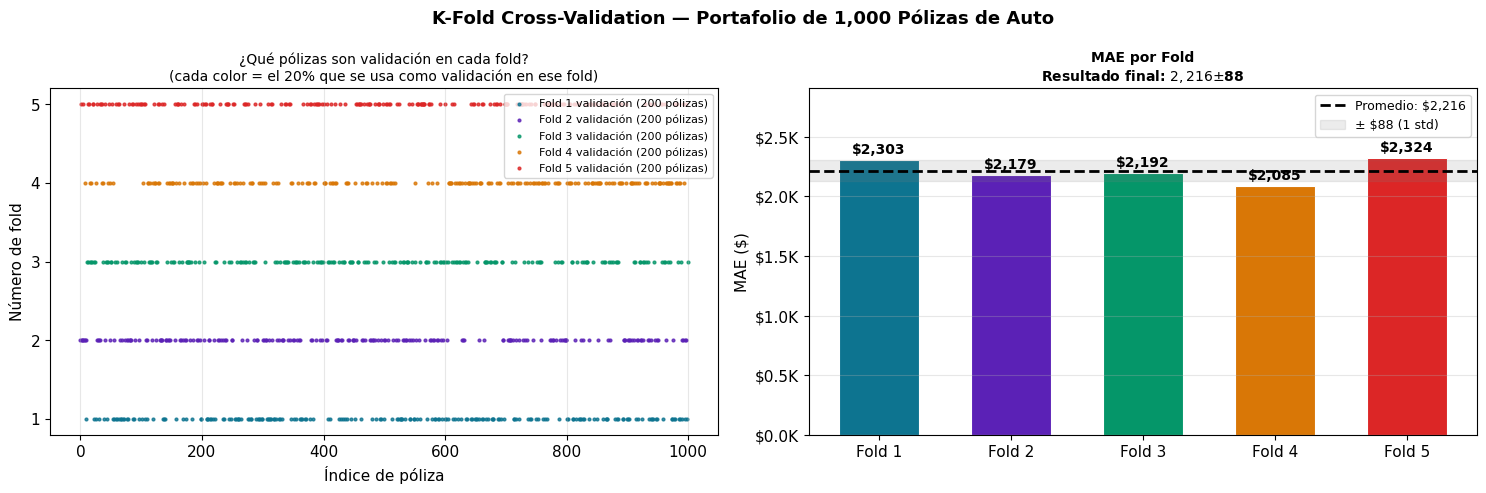

💾 Gráfica guardada: kfold_seguros.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('K-Fold Cross-Validation — Portafolio de 1,000 Pólizas de Auto',
             fontsize=13, fontweight='bold')

# ── Gráfica 1: Diagrama de los 5 folds ───────────────────────────────────────
ax1 = axes[0]
colores_fold = ['#0D7490', '#5B21B6', '#059669', '#D97706', '#DC2626']

for fold_num, (train_idx, val_idx) in enumerate(kf.split(X2), 1):
    # Graficar índices de validación como puntos
    ax1.scatter(
        val_idx,                          # posición en el dataset
        [fold_num] * len(val_idx),        # fila del fold
        s=4, alpha=0.8,
        color=colores_fold[fold_num - 1],
        label=f'Fold {fold_num} validación ({len(val_idx)} pólizas)'
    )

ax1.set_xlabel('Índice de póliza')
ax1.set_ylabel('Número de fold')
ax1.set_title('¿Qué pólizas son validación en cada fold?\n'
              '(cada color = el 20% que se usa como validación en ese fold)', fontsize=10)
ax1.set_yticks([1, 2, 3, 4, 5])
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3, axis='x')

# ── Gráfica 2: MAE por fold ───────────────────────────────────────────────────
ax2 = axes[1]
folds_num = range(1, 6)
bars = ax2.bar(folds_num, maes_por_fold, color=colores_fold,
               edgecolor='white', linewidth=0.8, width=0.6)

# Línea del promedio
ax2.axhline(mae_prom, color='black', linestyle='--', linewidth=2,
            label=f'Promedio: ${mae_prom:,.0f}')
# Banda de ±1 desviación estándar
ax2.axhspan(mae_prom - mae_std, mae_prom + mae_std,
            alpha=0.15, color='gray', label=f'± ${mae_std:,.0f} (1 std)')

# Etiquetas encima de cada barra
for bar, mae_val in zip(bars, maes_por_fold):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f'${mae_val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(folds_num)
ax2.set_xticklabels([f'Fold {i}' for i in folds_num])
ax2.set_ylabel('MAE ($)')
ax2.set_title(f'MAE por Fold\nResultado final: ${mae_prom:,.0f} ± ${mae_std:,.0f}',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(maes_por_fold) * 1.25)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.1f}K'))
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('kfold_seguros.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfica guardada: kfold_seguros.png")